<a href="https://colab.research.google.com/github/PedroAffonsoFaria/SSD_2026/blob/main/MVP_Previsao_Demanda_Alimentos_v.0.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# MVP de Machine Learning — Previsão de Demanda de Alimentos

**Tema:** previsão de demanda de refeições para apoiar planejamento de estoque e redução de desperdício.

**Tipo de problema:** regressão.

**Variável-alvo:** `num_orders`, que representa a quantidade de pedidos de uma refeição em um centro de atendimento em determinada semana.

**Objetivo:** treinar, comparar e avaliar modelos clássicos de Machine Learning capazes de prever a demanda futura de refeições com base em dados históricos de preço, promoções, centro de distribuição e características dos produtos.

Este notebook foi estruturado como relatório, com textos explicativos em Markdown e código Python executável no Google Colab.

## 1. Definição do problema

Empresas de alimentação, restaurantes, dark kitchens e operações de food service precisam estimar corretamente a demanda para planejar compras, produção, equipe e estoque. Quando a demanda é superestimada, há maior risco de desperdício de alimentos e capital parado em estoque. Quando é subestimada, há risco de ruptura, atrasos, perda de vendas e pior experiência do cliente.

Neste projeto, será utilizado um dataset público de previsão de demanda de alimentos. A ideia é construir um MVP de Machine Learning para prever a quantidade de pedidos por refeição, centro e semana.

### Pergunta principal

> É possível prever a demanda futura de refeições usando variáveis como semana, preço, promoções, centro de atendimento e características da refeição?

### Premissas e hipóteses

- O preço final e o preço base influenciam a quantidade de pedidos.
- A presença de promoções pode aumentar a demanda.
- Diferentes categorias e culinárias possuem padrões diferentes de consumo.
- Centros de atendimento diferentes podem apresentar comportamentos de demanda distintos.
- A demanda possui comportamento temporal, por isso a separação entre treino e teste deve respeitar a ordem das semanas.

## 2. Importação das bibliotecas

Nesta etapa, importamos as bibliotecas necessárias para manipulação dos dados, visualização, preparação, modelagem e avaliação dos modelos.

Foram utilizadas bibliotecas clássicas do ecossistema Python, como `pandas`, `numpy`, `matplotlib` e `scikit-learn`.

In [1]:
# ============================================================
# 2. Importação das bibliotecas
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import TransformedTargetRegressor

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, VotingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)

## 3. Carregamento dos dados

O trabalho exige que o dataset seja carregado por URL dentro do próprio notebook. Por isso, os arquivos abaixo são carregados diretamente de um repositório público no GitHub.

O dataset possui três tabelas principais:

- `train.csv`: histórico semanal de demanda por refeição e centro;
- `fulfilment_center_info.csv`: informações dos centros de atendimento;
- `meal_info.csv`: informações das refeições.

A variável-alvo utilizada será `num_orders`.

In [2]:
# ============================================================
# 3. Carregamento dos dados por URL
# ============================================================

TRAIN_URL = "https://raw.githubusercontent.com/hemachandarn/Food-Demand-Forecasting/main/train.csv"
CENTER_URL = "https://raw.githubusercontent.com/hemachandarn/Food-Demand-Forecasting/main/fulfilment_center_info.csv"
MEAL_URL = "https://raw.githubusercontent.com/hemachandarn/Food-Demand-Forecasting/main/meal_info.csv"

train = pd.read_csv(TRAIN_URL)
centers = pd.read_csv(CENTER_URL)
meals = pd.read_csv(MEAL_URL)

print("Dimensão da base train:", train.shape)
print("Dimensão da base centers:", centers.shape)
print("Dimensão da base meals:", meals.shape)

display(train.head())
display(centers.head())
display(meals.head())

Dimensão da base train: (456548, 9)
Dimensão da base centers: (77, 5)
Dimensão da base meals: (51, 3)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


## 4. União das bases

As três tabelas são unidas pelas chaves `center_id` e `meal_id`. Assim, cada observação passa a conter informações da demanda semanal, do centro de atendimento e da refeição.

In [3]:
# ============================================================
# 4. União das bases
# ============================================================

df = (
    train
    .merge(centers, on="center_id", how="left")
    .merge(meals, on="meal_id", how="left")
)

print("Dimensão da base final:", df.shape)
display(df.head())

Dimensão da base final: (456548, 15)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian


## 5. Descrição do dataset

Cada linha representa a demanda semanal de uma refeição em um centro específico.

### Principais atributos

- `week`: número da semana;
- `center_id`: identificador do centro de atendimento;
- `meal_id`: identificador da refeição;
- `checkout_price`: preço final;
- `base_price`: preço base;
- `emailer_for_promotion`: indicação de promoção por e-mail;
- `homepage_featured`: indicação se a refeição foi destacada na página inicial;
- `city_code`: código da cidade;
- `region_code`: código da região;
- `center_type`: tipo do centro;
- `op_area`: área operacional;
- `category`: categoria da refeição;
- `cuisine`: tipo de culinária;
- `num_orders`: quantidade de pedidos, variável-alvo.

### Restrições dos dados

A base é pública e anonimizada. O dataset foi escolhido por estar relacionado a um problema real de gestão de alimentos: previsão de demanda para melhor planejamento de produção e estoque.

In [4]:
# ============================================================
# 5. Análise exploratória inicial
# ============================================================

print("Informações gerais da base:")
display(df.info())

print("\nResumo estatístico das variáveis numéricas:")
display(df.describe())

print("\nValores ausentes por coluna:")
display(df.isna().sum())

print("\nRegistros duplicados:", df.duplicated().sum())

Informações gerais da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   city_code              456548 non-null  int64  
 10  region_code            456548 non-null  int64  
 11  center_type            456548 non-null  object 
 12  op_area                456548 non-null  float64
 13  category               456548 non-null  object 
 14  cuisine 

None


Resumo estatístico das variáveis numéricas:


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000,456548.000000,456548.000000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760,601.553399,56.614566,4.083590
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798,66.195914,17.641306,1.091686
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000,456.000000,23.000000,0.900000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000,553.000000,34.000000,3.600000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000,596.000000,56.000000,4.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000,651.000000,77.000000,4.500000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000,713.000000,93.000000,7.000000



Valores ausentes por coluna:


,0
id,0
week,0
center_id,0
meal_id,0
checkout_price,0
base_price,0
emailer_for_promotion,0
homepage_featured,0
num_orders,0
city_code,0



Registros duplicados: 0


## 6. Análise exploratória

Nesta etapa, analisamos a distribuição da variável-alvo e alguns padrões de demanda por semana, categoria, culinária e promoções.

Essa análise ajuda a entender o comportamento dos dados antes da modelagem.

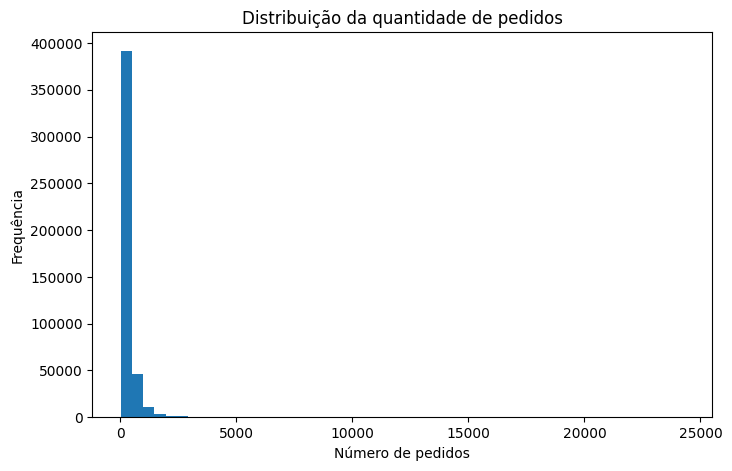

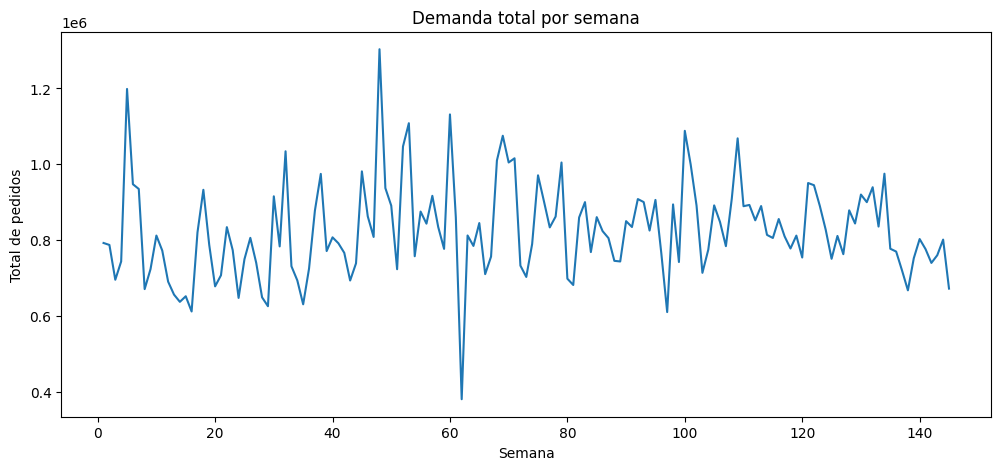

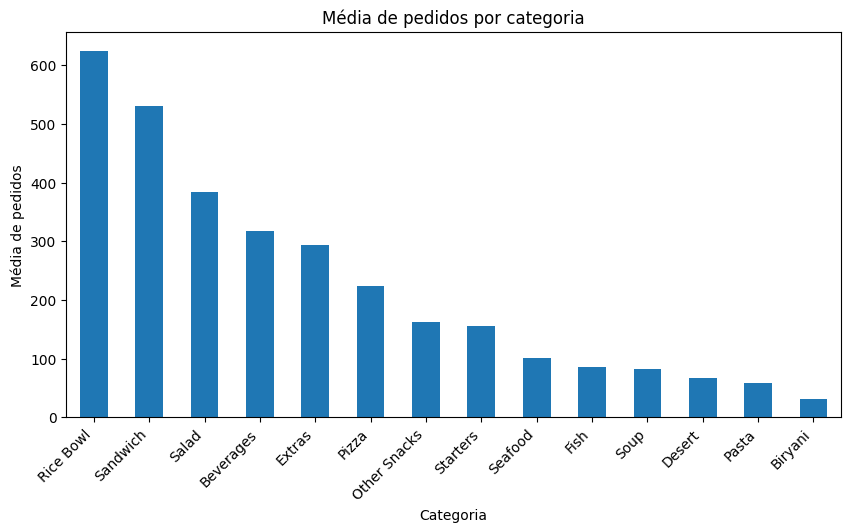

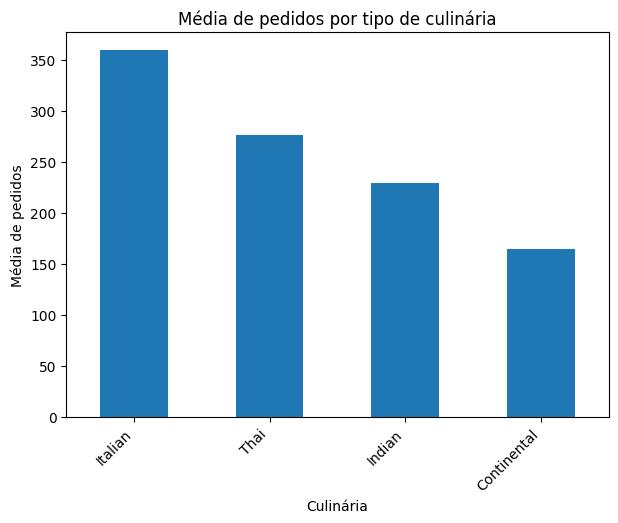

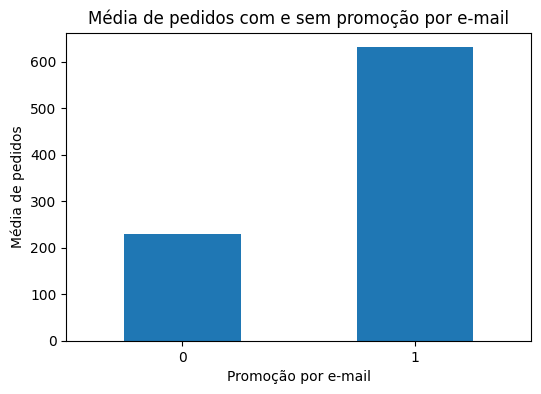

In [5]:
# ============================================================
# 6. Gráficos exploratórios
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(df["num_orders"], bins=50)
plt.title("Distribuição da quantidade de pedidos")
plt.xlabel("Número de pedidos")
plt.ylabel("Frequência")
plt.show()

orders_by_week = df.groupby("week")["num_orders"].sum()

plt.figure(figsize=(12, 5))
plt.plot(orders_by_week.index, orders_by_week.values)
plt.title("Demanda total por semana")
plt.xlabel("Semana")
plt.ylabel("Total de pedidos")
plt.show()

orders_by_category = (
    df.groupby("category")["num_orders"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
orders_by_category.plot(kind="bar")
plt.title("Média de pedidos por categoria")
plt.xlabel("Categoria")
plt.ylabel("Média de pedidos")
plt.xticks(rotation=45, ha="right")
plt.show()

orders_by_cuisine = (
    df.groupby("cuisine")["num_orders"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))
orders_by_cuisine.plot(kind="bar")
plt.title("Média de pedidos por tipo de culinária")
plt.xlabel("Culinária")
plt.ylabel("Média de pedidos")
plt.xticks(rotation=45, ha="right")
plt.show()

promo_analysis = df.groupby("emailer_for_promotion")["num_orders"].mean()

plt.figure(figsize=(6, 4))
promo_analysis.plot(kind="bar")
plt.title("Média de pedidos com e sem promoção por e-mail")
plt.xlabel("Promoção por e-mail")
plt.ylabel("Média de pedidos")
plt.xticks(rotation=0)
plt.show()

## 7. Preparação dos dados

Para melhorar a modelagem, serão criadas algumas variáveis derivadas:

- `discount_amount`: diferença entre preço base e preço final;
- `discount_pct`: percentual de desconto em relação ao preço base;
- `is_discounted`: indicação se houve desconto.

Além disso, os identificadores `center_id`, `meal_id`, `city_code` e `region_code` serão tratados como variáveis categóricas, pois seus números representam códigos e não grandezas contínuas.

Um ponto importante: como o problema é de previsão de demanda ao longo do tempo, a separação entre treino e teste será feita de forma temporal. As semanas mais antigas serão usadas para treino e as semanas mais recentes para teste. Isso evita uma avaliação artificialmente otimista causada por mistura aleatória de semanas.

In [6]:
# ============================================================
# 7. Preparação da base de modelagem
# ============================================================

df_model = df.copy()

# Criação de variáveis derivadas
df_model["discount_amount"] = df_model["base_price"] - df_model["checkout_price"]
df_model["discount_pct"] = df_model["discount_amount"] / df_model["base_price"]
df_model["is_discounted"] = (df_model["discount_amount"] > 0).astype(int)

# Remoção de identificador único da linha
df_model = df_model.drop(columns=["id"])

# Ordenação temporal
df_model = df_model.sort_values("week").reset_index(drop=True)

# Separação temporal: últimas 20% das semanas para teste
unique_weeks = np.sort(df_model["week"].unique())
split_position = int(len(unique_weeks) * 0.8)
train_weeks = unique_weeks[:split_position]
test_weeks = unique_weeks[split_position:]

train_df = df_model[df_model["week"].isin(train_weeks)].copy()
test_df = df_model[df_model["week"].isin(test_weeks)].copy()

X_train = train_df.drop(columns=["num_orders"])
y_train = train_df["num_orders"]

X_test = test_df.drop(columns=["num_orders"])
y_test = test_df["num_orders"]

print("Semanas de treino:", train_weeks.min(), "até", train_weeks.max())
print("Semanas de teste:", test_weeks.min(), "até", test_weeks.max())
print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)

# Variáveis categóricas por interpretação de negócio
categorical_features = [
    "center_id",
    "meal_id",
    "city_code",
    "region_code",
    "center_type",
    "category",
    "cuisine"
]

numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("\nVariáveis numéricas:", numeric_features)
print("\nVariáveis categóricas:", categorical_features)

Semanas de treino: 1 até 116
Semanas de teste: 117 até 145
Tamanho do treino: (361348, 16)
Tamanho do teste: (95200, 16)

Variáveis numéricas: ['week', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'op_area', 'discount_amount', 'discount_pct', 'is_discounted']

Variáveis categóricas: ['center_id', 'meal_id', 'city_code', 'region_code', 'center_type', 'category', 'cuisine']


## 8. Pré-processamento e pipelines

Foram criados dois tipos de pré-processamento:

1. **Pré-processamento para modelo linear:** usa padronização das variáveis numéricas e One-Hot Encoding nas categóricas.
2. **Pré-processamento para modelos de árvore:** usa imputação nas variáveis numéricas e Ordinal Encoding nas categóricas, mais adequado para modelos baseados em árvores e mais eficiente computacionalmente.

Também será utilizada transformação logarítmica da variável-alvo por meio do `TransformedTargetRegressor`, pois `num_orders` possui distribuição assimétrica. Isso reduz o efeito de valores muito altos e torna o treinamento mais estável.

In [7]:
# ============================================================
# 8. Pré-processamento e função de criação dos modelos
# ============================================================

linear_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

linear_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", linear_numeric_transformer, numeric_features),
        ("cat", linear_categorical_transformer, categorical_features)
    ]
)

tree_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

tree_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_transformer, numeric_features),
        ("cat", tree_categorical_transformer, categorical_features)
    ]
)

def build_model(preprocessor, regressor):
    """Cria pipeline completo com pré-processamento e transformação logarítmica do alvo."""
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", TransformedTargetRegressor(
            regressor=regressor,
            func=np.log1p,
            inverse_func=np.expm1
        ))
    ])

## 9. Métricas de avaliação

Como o problema é de regressão, serão utilizadas as seguintes métricas:

- **MAE:** erro absoluto médio. Fácil de interpretar na escala original de pedidos.
- **RMSE:** penaliza erros grandes com mais intensidade.
- **RMSLE:** mede erro relativo e é útil quando a variável-alvo é assimétrica.
- **R²:** indica a proporção da variabilidade explicada pelo modelo.

A métrica principal será o **RMSLE**, pois em previsão de demanda é importante avaliar erros relativos e reduzir o impacto de demandas muito altas.

In [8]:
# ============================================================
# 9. Funções auxiliares de avaliação
# ============================================================

def rmsle(y_true, y_pred):
    """Calcula Root Mean Squared Logarithmic Error."""
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))


def evaluate_predictions(y_true, y_pred):
    """Retorna métricas de avaliação em formato de dicionário."""
    y_pred = np.maximum(y_pred, 0)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "RMSLE": rmsle(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Treina o modelo, gera previsões e retorna métricas."""
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred = np.maximum(pred, 0)

    metrics = evaluate_predictions(y_test, pred)
    metrics["Modelo"] = name

    return metrics, pred


rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

## 10. Modelagem e treinamento

Serão comparados quatro modelos:

1. **Dummy Regressor:** baseline simples, usado como referência mínima.
2. **Ridge Regression:** modelo linear regularizado.
3. **Random Forest Regressor:** ensemble de árvores, capaz de capturar relações não lineares.
4. **HistGradientBoosting Regressor:** modelo de boosting eficiente para dados tabulares.

A comparação inicial será feita na base de teste temporal.

In [9]:
# ============================================================
# 10. Definição dos modelos
# ============================================================

models = {
    "Baseline - Dummy": build_model(
        tree_preprocessor,
        DummyRegressor(strategy="median")
    ),

    "Ridge Regression": build_model(
        linear_preprocessor,
        Ridge(alpha=1.0)
    ),

    "Random Forest": build_model(
        tree_preprocessor,
        RandomForestRegressor(
            n_estimators=80,
            max_depth=18,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),

    "HistGradientBoosting": build_model(
        tree_preprocessor,
        HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.08,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE
        )
    )
}

In [10]:
# ============================================================
# 11. Treinamento e avaliação inicial
# ============================================================

results = []
predictions = {}

for name, model in models.items():
    metrics, pred = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results.append(metrics)
    predictions[name] = pred

results_df = (
    pd.DataFrame(results)
    [["Modelo", "MAE", "RMSE", "RMSLE", "R2"]]
    .sort_values("RMSLE")
)

display(results_df)

,Modelo,MAE,RMSE,RMSLE,R2
3,HistGradientBoosting,91.530634,204.471867,0.564583,0.686541
2,Random Forest,88.961051,193.104488,0.598588,0.720425
1,Ridge Regression,103.929714,226.198942,0.629805,0.616386
0,Baseline - Dummy,188.883866,382.026797,1.180554,-0.094211


## 11. Validação cruzada

Como existe uma dimensão temporal no problema, será usada a validação cruzada com `TimeSeriesSplit`, que preserva a ordem dos dados e evita que informações futuras sejam usadas para prever o passado.

Essa escolha é mais adequada para previsão de demanda do que o `KFold` aleatório.

In [11]:
# ============================================================
# 12. Validação cruzada temporal
# ============================================================

# A base de treino já está ordenada por semana.
tscv = TimeSeriesSplit(n_splits=3)

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "R2": "r2",
            "RMSLE": rmsle_scorer
        },
        n_jobs=-1
    )

    cv_results.append({
        "Modelo": name,
        "MAE_CV_medio": -scores["test_MAE"].mean(),
        "MAE_CV_desvio": scores["test_MAE"].std(),
        "RMSLE_CV_medio": -scores["test_RMSLE"].mean(),
        "RMSLE_CV_desvio": scores["test_RMSLE"].std(),
        "R2_CV_medio": scores["test_R2"].mean(),
        "R2_CV_desvio": scores["test_R2"].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("RMSLE_CV_medio")
display(cv_results_df)

,Modelo,MAE_CV_medio,MAE_CV_desvio,RMSLE_CV_medio,RMSLE_CV_desvio,R2_CV_medio,R2_CV_desvio
3,HistGradientBoosting,97.572243,5.352535,0.573225,0.008133,0.683276,0.019734
2,Random Forest,95.434837,4.893430,0.577324,0.009720,0.686256,0.029274
1,Ridge Regression,113.178369,6.569112,0.651033,0.008586,0.601995,0.049926
0,Baseline - Dummy,206.000255,7.110266,1.212183,0.010709,-0.105957,0.018518


## 12. Otimização de hiperparâmetros

Será realizada uma busca aleatória (`RandomizedSearchCV`) para otimizar o modelo `HistGradientBoostingRegressor`.

A escolha desse modelo ocorre porque métodos de boosting costumam apresentar bom desempenho em problemas tabulares e conseguem capturar relações não lineares entre preço, promoção, centro, categoria e demanda.

A busca usa validação temporal e RMSLE como métrica principal.

In [12]:
# ============================================================
# 13. Otimização de hiperparâmetros
# ============================================================

hgb_pipeline = build_model(
    tree_preprocessor,
    HistGradientBoostingRegressor(random_state=RANDOM_STATE)
)

param_distributions = {
    "model__regressor__max_iter": [100, 200, 300],
    "model__regressor__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "model__regressor__max_leaf_nodes": [15, 31, 63],
    "model__regressor__l2_regularization": [0.0, 0.01, 0.1, 1.0]
}

search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring=rmsle_scorer,
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Melhores hiperparâmetros:")
print(search.best_params_)

best_hgb = search.best_estimator_

pred_best_hgb = best_hgb.predict(X_test)
pred_best_hgb = np.maximum(pred_best_hgb, 0)

best_hgb_metrics = evaluate_predictions(y_test, pred_best_hgb)
best_hgb_metrics["Modelo"] = "HistGradientBoosting Otimizado"

display(pd.DataFrame([best_hgb_metrics])[["Modelo", "MAE", "RMSE", "RMSLE", "R2"]])

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores hiperparâmetros:
{'model__regressor__max_leaf_nodes': 31, 'model__regressor__max_iter': 300, 'model__regressor__learning_rate': 0.08, 'model__regressor__l2_regularization': 0.1}


,Modelo,MAE,RMSE,RMSLE,R2
0,HistGradientBoosting Otimizado,88.463503,199.393072,0.548646,0.701919


## 13. Comitê de modelos

Também será testado um comitê de modelos por meio do `VotingRegressor`. A ideia é combinar previsões de modelos diferentes para verificar se o ensemble melhora a capacidade preditiva.

Neste caso, serão utilizados Ridge, Random Forest e HistGradientBoosting. Para manter compatibilidade entre os modelos dentro do comitê, será utilizado o pré-processamento baseado em codificação ordinal.

In [13]:
# ============================================================
# 14. Comitê de modelos
# ============================================================

voting_model = build_model(
    tree_preprocessor,
    VotingRegressor(
        estimators=[
            ("ridge", Ridge(alpha=1.0)),
            ("rf", RandomForestRegressor(
                n_estimators=60,
                max_depth=16,
                min_samples_leaf=3,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )),
            ("hgb", HistGradientBoostingRegressor(
                max_iter=200,
                learning_rate=0.08,
                max_leaf_nodes=31,
                random_state=RANDOM_STATE
            ))
        ],
        n_jobs=-1
    )
)

voting_metrics, pred_voting = evaluate_model(
    "Voting Regressor",
    voting_model,
    X_train,
    y_train,
    X_test,
    y_test
)

display(pd.DataFrame([voting_metrics])[["Modelo", "MAE", "RMSE", "RMSLE", "R2"]])

,Modelo,MAE,RMSE,RMSLE,R2
0,Voting Regressor,108.537713,243.428646,0.625759,0.55572


## 14. Comparação final dos modelos

Nesta etapa, os modelos iniciais, o modelo otimizado e o comitê são comparados em conjunto.

A melhor solução será definida principalmente pelo menor RMSLE, considerando também MAE, RMSE e R².

In [14]:
# ============================================================
# 15. Comparação final dos modelos
# ============================================================

final_results = pd.concat([
    results_df,
    pd.DataFrame([best_hgb_metrics]),
    pd.DataFrame([voting_metrics])
], ignore_index=True)

final_results = (
    final_results[["Modelo", "MAE", "RMSE", "RMSLE", "R2"]]
    .sort_values("RMSLE")
    .reset_index(drop=True)
)

display(final_results)

,Modelo,MAE,RMSE,RMSLE,R2
0,HistGradientBoosting Otimizado,88.463503,199.393072,0.548646,0.701919
1,HistGradientBoosting,91.530634,204.471867,0.564583,0.686541
2,Random Forest,88.961051,193.104488,0.598588,0.720425
3,Voting Regressor,108.537713,243.428646,0.625759,0.555720
4,Ridge Regression,103.929714,226.198942,0.629805,0.616386
5,Baseline - Dummy,188.883866,382.026797,1.180554,-0.094211


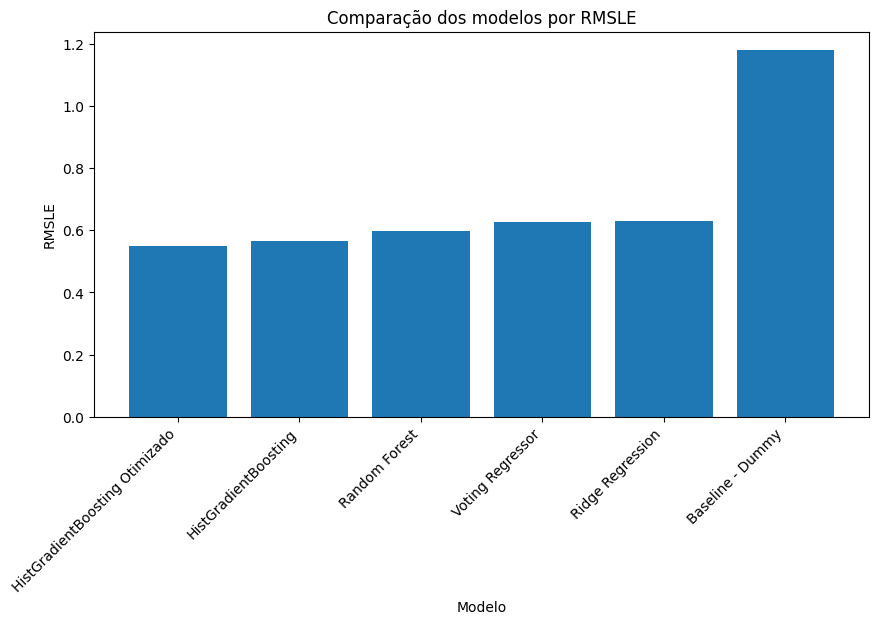

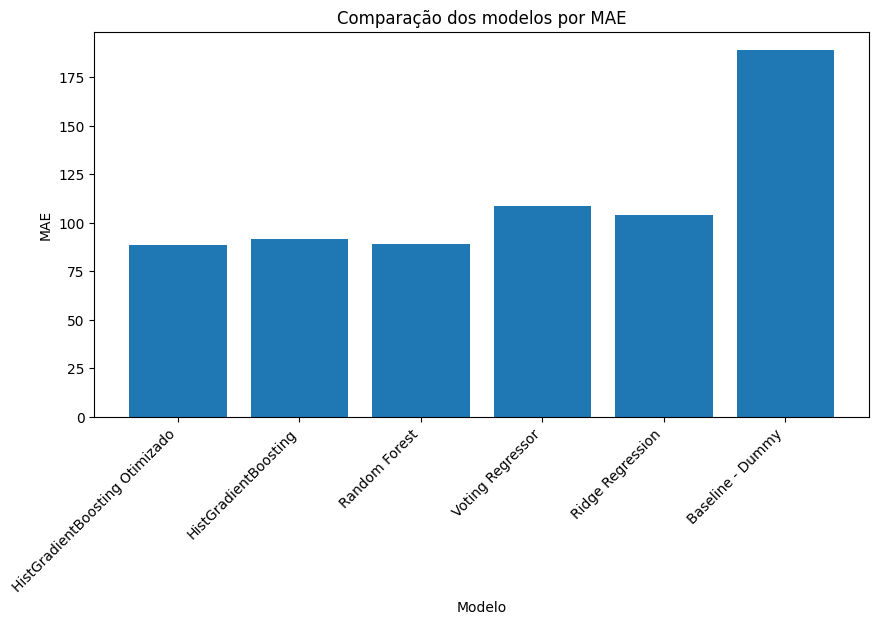

In [15]:
# ============================================================
# 16. Visualização da comparação final
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(final_results["Modelo"], final_results["RMSLE"])
plt.title("Comparação dos modelos por RMSLE")
plt.xlabel("Modelo")
plt.ylabel("RMSLE")
plt.xticks(rotation=45, ha="right")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(final_results["Modelo"], final_results["MAE"])
plt.title("Comparação dos modelos por MAE")
plt.xlabel("Modelo")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.show()

## 15. Análise: valores reais x previstos

Para avaliar visualmente o comportamento do melhor modelo, comparamos os valores reais e previstos na base de teste.

Quanto mais próximos os pontos estiverem da linha diagonal, melhor será a qualidade da previsão.

,valor_real,valor_previsto
0,41,42.485429
1,13,37.195913
2,312,182.302728
3,67,133.636942
4,1203,978.794795
5,1390,608.586361
6,918,547.624317
7,325,455.120212
8,68,48.474800
9,67,47.833736


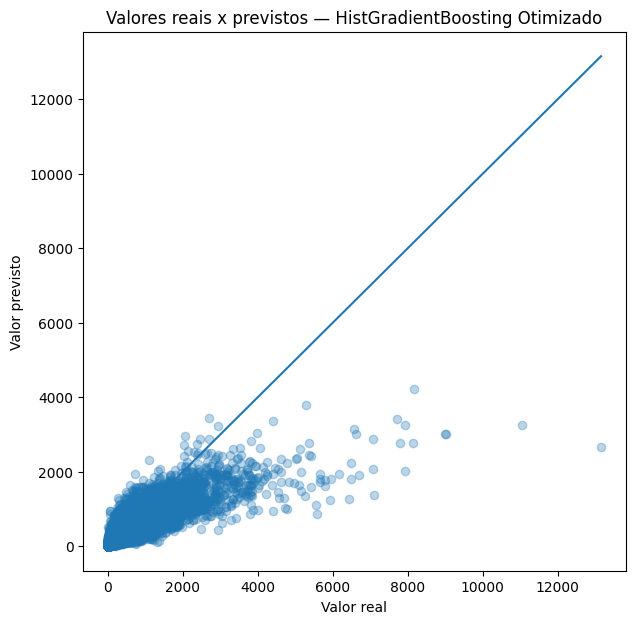

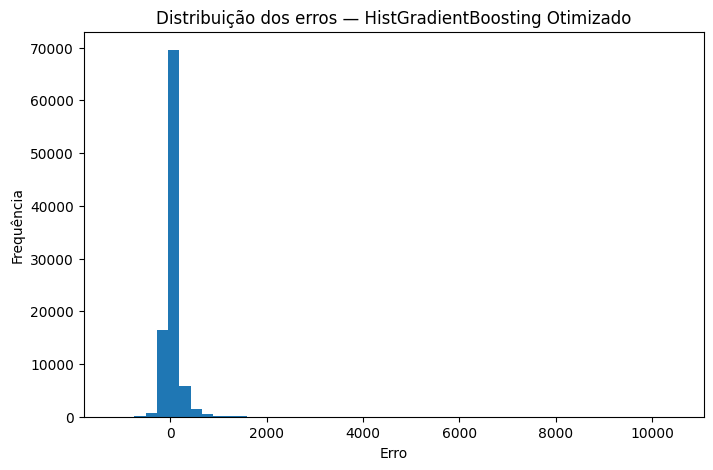

In [16]:
# ============================================================
# 17. Análise: valores reais x previstos
# ============================================================

best_model_name = final_results.iloc[0]["Modelo"]

if best_model_name == "HistGradientBoosting Otimizado":
    best_pred = pred_best_hgb
elif best_model_name == "Voting Regressor":
    best_pred = pred_voting
else:
    best_pred = predictions[best_model_name]

comparison_df = pd.DataFrame({
    "valor_real": y_test.values,
    "valor_previsto": best_pred
})

display(comparison_df.head(20))

plt.figure(figsize=(7, 7))
plt.scatter(comparison_df["valor_real"], comparison_df["valor_previsto"], alpha=0.3)
max_value = max(comparison_df["valor_real"].max(), comparison_df["valor_previsto"].max())
plt.plot([0, max_value], [0, max_value])
plt.title(f"Valores reais x previstos — {best_model_name}")
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.show()

comparison_df["erro"] = comparison_df["valor_real"] - comparison_df["valor_previsto"]

plt.figure(figsize=(8, 5))
plt.hist(comparison_df["erro"], bins=50)
plt.title(f"Distribuição dos erros — {best_model_name}")
plt.xlabel("Erro")
plt.ylabel("Frequência")
plt.show()

## 16. Importância das variáveis

Para interpretar o modelo, será utilizada a importância das variáveis do melhor modelo de árvore quando possível.

Essa análise ajuda a identificar quais fatores mais influenciaram a previsão de demanda.

In [17]:
# ============================================================
# 18. Importância das variáveis, quando aplicável
# ============================================================

def show_feature_importance(model, feature_names):
    """Exibe a importância das variáveis para modelos que possuem feature_importances_."""
    regressor = model.named_steps["model"].regressor_

    if hasattr(regressor, "feature_importances_"):
        importances = pd.DataFrame({
            "feature": feature_names,
            "importance": regressor.feature_importances_
        }).sort_values("importance", ascending=False)

        display(importances.head(15))

        plt.figure(figsize=(10, 5))
        plt.bar(importances.head(15)["feature"], importances.head(15)["importance"])
        plt.title("Top 15 variáveis mais importantes")
        plt.xlabel("Variável")
        plt.ylabel("Importância")
        plt.xticks(rotation=45, ha="right")
        plt.show()
    else:
        print("O melhor modelo não possui atributo direto feature_importances_.")

best_model_object = None

if best_model_name == "HistGradientBoosting Otimizado":
    best_model_object = best_hgb
elif best_model_name in models:
    best_model_object = models[best_model_name]
elif best_model_name == "Voting Regressor":
    best_model_object = voting_model

if best_model_object is not None:
    try:
        best_model_object.fit(X_train, y_train)
        transformed_feature_names = numeric_features + categorical_features
        show_feature_importance(best_model_object, transformed_feature_names)
    except Exception as e:
        print("Não foi possível exibir a importância das variáveis para este modelo.")
        print("Motivo:", e)

O melhor modelo não possui atributo direto feature_importances_.


## 17. Análise dos resultados

Após o treinamento e avaliação dos modelos, é possível comparar o desempenho com base nas métricas MAE, RMSE, RMSLE e R².

### Interpretação das métricas

- O **MAE** mostra, em média, quantos pedidos o modelo erra na escala original.
- O **RMSE** penaliza erros grandes, sendo útil quando grandes desvios são especialmente problemáticos para a operação.
- O **RMSLE** é adequado para esse problema porque a demanda possui distribuição assimétrica e erros relativos são relevantes.
- O **R²** indica quanto da variação da demanda foi explicada pelo modelo.

### Principais achados esperados

Espera-se que o modelo baseline apresente o pior desempenho, pois ele ignora as variáveis explicativas e prevê apenas uma medida central da demanda. Modelos baseados em árvores e boosting tendem a ter desempenho superior porque capturam relações não lineares entre preço, promoção, centro, refeição e demanda.

A separação temporal torna a avaliação mais realista, pois o modelo é testado em semanas futuras, simulando melhor o uso prático em uma operação de alimentação.

## 18. Conclusão

Este projeto desenvolveu um MVP de Machine Learning para previsão de demanda de refeições. O problema foi tratado como regressão, usando como variável-alvo a quantidade de pedidos (`num_orders`).

Foram realizadas as etapas de carregamento dos dados por URL, união das tabelas, análise exploratória, preparação dos dados, criação de variáveis derivadas, separação temporal entre treino e teste, criação de pipelines, validação cruzada temporal, treinamento de diferentes modelos, otimização de hiperparâmetros e comparação final dos resultados.

A melhor solução deve ser escolhida com base principalmente no menor RMSLE, sem ignorar MAE, RMSE e R². Do ponto de vista de negócio, o modelo pode apoiar o planejamento de compras, produção e estoque em restaurantes e empresas de alimentação, contribuindo para redução de desperdícios e melhoria da eficiência operacional.

Como próximos passos, seria possível incluir dados externos, como clima, feriados, eventos locais e campanhas comerciais, além de testar modelos específicos de séries temporais.

## 19. Checklist do trabalho

### Definição do problema

**Qual é a descrição do problema?**  
Prever a quantidade de pedidos de refeições a partir de dados históricos e operacionais.

**Premissas ou hipóteses:**  
Preço, promoções, categoria da refeição, tipo de centro e semana influenciam a demanda.

**Restrições ou condições dos dados:**  
Foi utilizada uma base pública, carregada por URL e anonimizada. A separação treino/teste respeitou a ordem temporal das semanas.

**Descrição do dataset:**  
A base contém informações semanais de demanda, características dos centros de atendimento e informações das refeições.

### Preparação dos dados

**Separação treino/teste:**  
A base foi dividida temporalmente: semanas antigas para treino e semanas recentes para teste.

**Validação cruzada:**  
Foi utilizada validação cruzada temporal com `TimeSeriesSplit`, mais adequada para previsão de demanda.

**Transformações:**  
Variáveis numéricas receberam imputação e, quando necessário, padronização. Variáveis categóricas foram codificadas por One-Hot Encoding ou Ordinal Encoding. A variável-alvo recebeu transformação logarítmica.

**Feature engineering:**  
Foram criadas variáveis de desconto: valor do desconto, percentual de desconto e indicação se houve desconto.

### Modelagem e treinamento

**Algoritmos selecionados:**  
Dummy Regressor, Ridge Regression, Random Forest, HistGradientBoosting e Voting Regressor.

**Hiperparâmetros:**  
Foram definidos parâmetros iniciais e realizada otimização do HistGradientBoosting com `RandomizedSearchCV`.

**Underfitting e overfitting:**  
A comparação entre validação cruzada e teste ajuda a observar possíveis problemas de underfitting ou overfitting.

**Método avançado:**  
Foi testado um comitê de modelos com `VotingRegressor`.

### Avaliação de resultados

**Métricas:**  
MAE, RMSE, RMSLE e R².

**Comparação entre modelos:**  
Os modelos foram comparados em uma tabela final e em gráficos.

**Melhor solução:**  
A melhor solução é a que apresenta menor RMSLE na base de teste temporal, considerando também as demais métricas e a interpretação de negócio.